> Zendesk, Freshdesk, Jira, ServiceNow, Zoho Desk, OTRS — they all have 4+ average ratings on Capterra. But when you actually read what their happiest customers wrote, up to 18% of them sound frustrated. This notebook finds out who's hiding the most, and why.

# Capterra review sentiment vs. star ratings

This notebook turns review text into a practical signal for customer frustration. Instead of trusting star ratings alone, it looks for the hidden mismatch between what a customer says and what a rating suggests.


In [19]:
import os
import sqlite3
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

DATA_PATH = '../data/capterra_reviews.csv'
DB_PATH = '../notebooks/capterra_reviews.sqlite'

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

reviews = pd.read_csv(DATA_PATH)
reviews[['overall_text','pros_text','cons_text','title']] = reviews[['overall_text','pros_text','cons_text','title']].fillna('')
reviews['combined_text'] = (
    reviews['overall_text'].astype(str) + ' ' +
    reviews['pros_text'].astype(str) + ' ' +
    reviews['cons_text'].astype(str)
)

reviews.head()

,ticket_system,title,overall_text,pros_text,cons_text,overall_rating,ease_of_use,customer_service,features,value_for_money,...,Automated Ticket Routing,Status Tracking and Updates,Priority and SLA Management,Customer and Agent Portals,Knowledge Base Integration,Email Notifications and Alerts,Reporting and Analytics,Customizable Workflows,"Multi-Channel Support (Email, Chat, Phone)",combined_text
0,Zoho Desk,Excellent solution that meets all of our requi...,Zoho Desk is a top-tier platform for developin...,"As a ticketing and customer service platform, ...",Although the program provides a great return o...,5,5.0,5.0,5.0,4.0,...,-1,1,1,0,0,0,1,0,0,Zoho Desk is a top-tier platform for developin...
1,Zoho Desk,Offers multiple options to help customers get ...,"Provides web-based customer support, reducing ...","In the period I have used Zoho Desk, I have ex...",Zoho Desk gives maximum scalability and return...,5,5.0,5.0,5.0,5.0,...,0,0,0,0,1,0,0,1,0,"Provides web-based customer support, reducing ..."
2,Zoho Desk,"Zoho Desk isn't a favourite option of mine, bu...","Zoho Desk is a great tool with many features, ...",Zoho Desk offers a range of tools to make sure...,Unfortunately the creation and customisation o...,3,3.0,4.0,3.0,3.0,...,0,1,0,1,1,0,0,-1,1,"Zoho Desk is a great tool with many features, ..."
3,Zoho Desk,Keep your customers happy,"Zoho Desk is very responsive and fast, is pack...",In my line of business the returning customers...,We have experienced slow loading some time ago...,5,5.0,5.0,5.0,5.0,...,0,-1,0,1,1,0,0,0,1,"Zoho Desk is very responsive and fast, is pack..."
4,Zoho Desk,A fantastic tool for answering customer queries,"Questions about orders or invoices, tickets, a...",Managing a staff to answer client questions an...,"Getting help, including clear responses to my ...",4,5.0,4.0,5.0,5.0,...,0,0,0,1,0,-1,0,1,0,"Questions about orders or invoices, tickets, a..."


# Capterra review sentiment vs. star ratings

This notebook loads Capterra reviews for six ITSM tools into a local SQLite database, applies a lightweight sentiment analysis pass, and compares the text sentiment to the star rating to spot reviews where the score looks positive on paper but carries frustration in the writing.

The goal is not just to produce a final number, but to make the comparison transparent and rerunnable.

## Architecture Overview

```text
Capterra CSV
  -> SQL database (PromptathonDb / SQLite in notebook)
  -> VADER Sentiment Scoring
  -> Liar Score Detection
  -> Aspect Classification
  -> Semantic Search
  -> Per-Tool Insights
```

In [20]:
import sqlite3
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

cur.execute('''
CREATE TABLE reviews (
    review_id INTEGER PRIMARY KEY AUTOINCREMENT,
    ticket_system TEXT,
    title TEXT,
    overall_text TEXT,
    pros_text TEXT,
    cons_text TEXT,
    overall_rating INTEGER,
    ease_of_use REAL,
    customer_service REAL,
    features REAL,
    value_for_money REAL,
    likelihood_to_recommend REAL,
    combined_text TEXT,
    sentiment_compound REAL,
    sentiment_label TEXT,
    sentiment_score_15 REAL,
    rating_gap REAL,
    liar_score INTEGER
)
''')

analyzer = SentimentIntensityAnalyzer()

for _, row in reviews.iterrows():
    text = str(row['combined_text'])
    compound = analyzer.polarity_scores(text)['compound']
    sentiment_label = 'positive' if compound >= 0.05 else 'negative' if compound <= -0.05 else 'neutral'
    sentiment_score_15 = 3 + 2 * compound
    rating_gap = int(row['overall_rating']) - sentiment_score_15
    liar_score = 1 if (int(row['overall_rating']) >= 4 and sentiment_label != 'positive') else 0
    cur.execute('''
        INSERT INTO reviews (
            ticket_system, title, overall_text, pros_text, cons_text,
            overall_rating, ease_of_use, customer_service, features, value_for_money,
            likelihood_to_recommend, combined_text, sentiment_compound, sentiment_label,
            sentiment_score_15, rating_gap, liar_score
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (
        row['ticket_system'], row['title'], row['overall_text'], row['pros_text'], row['cons_text'],
        int(row['overall_rating']),
        None if pd.isna(row['ease_of_use']) else float(row['ease_of_use']),
        None if pd.isna(row['customer_service']) else float(row['customer_service']),
        None if pd.isna(row['features']) else float(row['features']),
        None if pd.isna(row['value_for_money']) else float(row['value_for_money']),
        None if pd.isna(row['likelihood_to_recommend']) else float(row['likelihood_to_recommend']),
        text, compound, sentiment_label, sentiment_score_15, rating_gap, liar_score
    ))

conn.commit()
conn.close()

print(f'Imported {len(reviews)} reviews into {DB_PATH}')

Imported 4899 reviews into ../notebooks/capterra_reviews.sqlite


## Inspect the data and review distribution

The next cells show the available columns, the first few rows, and the distribution of ratings and tools from SQL.

In [21]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

print('Columns:')
print(pd.read_sql_query("SELECT * FROM reviews LIMIT 0", conn).columns.tolist())
print('\nFirst 5 rows:')
print(pd.read_sql_query("SELECT ticket_system, title, overall_rating, sentiment_label, sentiment_compound, liar_score FROM reviews ORDER BY review_id LIMIT 5", conn))
print('\nTool counts:')
print(pd.read_sql_query("SELECT ticket_system, COUNT(*) AS review_count FROM reviews GROUP BY ticket_system ORDER BY review_count DESC", conn))
print('\nStar rating distribution:')
print(pd.read_sql_query("SELECT overall_rating, COUNT(*) AS review_count FROM reviews GROUP BY overall_rating ORDER BY overall_rating", conn))

conn.close()

Columns:
['review_id', 'ticket_system', 'title', 'overall_text', 'pros_text', 'cons_text', 'overall_rating', 'ease_of_use', 'customer_service', 'features', 'value_for_money', 'likelihood_to_recommend', 'combined_text', 'sentiment_compound', 'sentiment_label', 'sentiment_score_15', 'rating_gap', 'liar_score']

First 5 rows:
  ticket_system                                              title  \
0     Zoho Desk  Excellent solution that meets all of our requi...   
1     Zoho Desk  Offers multiple options to help customers get ...   
2     Zoho Desk  Zoho Desk isn't a favourite option of mine, bu...   
3     Zoho Desk                          Keep your customers happy   
4     Zoho Desk    A fantastic tool for answering customer queries   

   overall_rating sentiment_label  sentiment_compound  liar_score  
0               5        positive              0.9878           0  
1               5        positive              0.9781           0  
2               3        positive              0.9

## Compare sentiment and star ratings

This section joins the text sentiment score to the star rating and highlights reviews whose rating is high but whose text sentiment is not strongly positive.

In [22]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

summary = pd.read_sql_query('''
SELECT
    overall_rating,
    sentiment_label,
    COUNT(*) AS review_count,
    AVG(sentiment_compound) AS avg_sentiment_compound,
    AVG(rating_gap) AS avg_rating_gap
FROM reviews
GROUP BY overall_rating, sentiment_label
ORDER BY overall_rating, sentiment_label
''', conn)
print(summary)

print('\nHigh-rating but non-positive text reviews:')
print(pd.read_sql_query('''
SELECT ticket_system, title, overall_rating, sentiment_label, sentiment_compound, rating_gap
FROM reviews
WHERE overall_rating >= 4 AND sentiment_label != 'positive'
ORDER BY rating_gap ASC
LIMIT 15
''', conn))

conn.close()

    overall_rating sentiment_label  review_count  avg_sentiment_compound  \
0                1        negative            15               -0.725313   
1                1         neutral             2                0.000000   
2                1        positive            16                0.762088   
3                2        negative            14               -0.610871   
4                2         neutral             3                0.022500   
5                2        positive            28                0.767796   
6                3        negative            30               -0.515683   
7                3         neutral            20                0.002860   
8                3        positive           198                0.730641   
9                4        negative            74               -0.385220   
10               4         neutral           104                0.000187   
11               4        positive          1448                0.807750   
12          

## Find the most likely Liar Score by tool

The next query aggregates the results by ITSM tool and shows which platform has the strongest concentration of reviews that look positive in rating but less positive in text.

In [23]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

by_tool = pd.read_sql_query('''
SELECT
    ticket_system,
    COUNT(*) AS review_count,
    SUM(liar_score) AS liar_count,
    ROUND(100.0 * AVG(liar_score), 2) AS liar_pct,
    ROUND(AVG(sentiment_compound), 3) AS avg_sentiment_compound,
    ROUND(AVG(overall_rating), 3) AS avg_rating
FROM reviews
GROUP BY ticket_system
ORDER BY liar_count DESC, liar_pct DESC
''', conn)
print(by_tool)

conn.close()

             ticket_system  review_count  liar_count  liar_pct  \
0                Zoho Desk          1400         118      8.43   
1  Jira Service Management           668         112     16.77   
2                  Zendesk          1475         107      7.25   
3                Freshdesk          1025          51      4.98   
4               ServiceNow           242          44     18.18   
5                     otrs            89           5      5.62   

   avg_sentiment_compound  avg_rating  
0                   0.694       4.521  
1                   0.587       4.470  
2                   0.738       4.509  
3                   0.783       4.548  
4                   0.555       4.471  
5                   0.734       4.438  


## Visualize the results

The final cells create simple charts for the comparison so the patterns are easier to see at a glance.

## Semantic Search: Finding Similar Complaints Across Tools

This section adds a lightweight semantic search layer. It uses sentence embeddings to turn complaint text into vectors, then retrieves the most similar complaints from other ITSM tools for a user-supplied query such as "slow ticket routing".

The idea is to find the same underlying issue even when the wording differs across products.

In [24]:
import sqlite3
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

conn = sqlite3.connect(DB_PATH)
complaints = pd.read_sql_query('''
SELECT review_id, ticket_system, title, overall_text, pros_text, cons_text, overall_rating, sentiment_compound, sentiment_label, rating_gap
FROM reviews
WHERE overall_rating <= 3 OR sentiment_label != 'positive'
ORDER BY review_id
''', conn)
conn.close()

# Build a compact complaint text field for semantic matching.
complaints['complaint_text'] = (
    complaints['title'].fillna('') + ' ' +
    complaints['overall_text'].fillna('') + ' ' +
    complaints['cons_text'].fillna('')
).str.strip()
complaints = complaints[complaints['complaint_text'] != '']

print(f'Loaded {len(complaints)} complaint-like reviews for semantic search.')

# Load a lightweight sentence embedding model once.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings for the complaint texts.
texts = complaints['complaint_text'].tolist()
embeddings = model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)

# Example query: user can change this to search for other issues.
query = 'slow ticket routing'
query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)

scores = cosine_similarity(query_embedding, embeddings)[0]
ranked = complaints.copy()
ranked['similarity'] = scores
ranked = ranked.sort_values('similarity', ascending=False).head(10)

ranked[['ticket_system','overall_rating','sentiment_label','similarity','complaint_text']].head(10)

Loaded 717 complaint-like reviews for semantic search.


,ticket_system,overall_rating,sentiment_label,similarity,complaint_text
542,ServiceNow,3,positive,0.543137,"Alright for what it is Not bad at all, would r..."
219,Freshdesk,5,negative,0.472185,Freshdesk is an awesome ticket management tool...
637,Jira Service Management,4,neutral,0.463323,Great Daily Enterprise Tool Pros:--Great roadm...
395,Zendesk,4,negative,0.445594,Nice ticketing system with too many bells and ...
145,Zoho Desk,3,positive,0.444795,"Good at budget, but slow and need to fix bugs ..."
225,Freshdesk,1,negative,0.443850,Regrettable decision The only benefit we reall...
160,Zoho Desk,5,neutral,0.441860,"Easy to use, quick to learn Pros:The software ..."
508,Zendesk,3,positive,0.441516,A simple tool that lacks some features Pros:Ze...
90,Zoho Desk,4,neutral,0.440691,Best ticketing system for a reason Pros:Value ...
749,otrs,3,positive,0.440482,Decent Ticket Tracking Tool Pros:The fact that...


In [25]:
def search_similar_complaints(query, top_n=10, exclude_tool=None):
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores = cosine_similarity(query_embedding, embeddings)[0]
    ranked = complaints.copy()
    ranked['similarity'] = scores
    if exclude_tool is not None:
        ranked = ranked[ranked['ticket_system'] != exclude_tool]
    ranked = ranked.sort_values('similarity', ascending=False).head(top_n)
    return ranked[['ticket_system','overall_rating','sentiment_label','rating_gap','similarity','complaint_text']]

search_similar_complaints('slow ticket routing', top_n=8)

,ticket_system,overall_rating,sentiment_label,rating_gap,similarity,complaint_text
542,ServiceNow,3,positive,-1.7074,0.543137,"Alright for what it is Not bad at all, would r..."
219,Freshdesk,5,negative,2.7636,0.472185,Freshdesk is an awesome ticket management tool...
637,Jira Service Management,4,neutral,1.0000,0.463323,Great Daily Enterprise Tool Pros:--Great roadm...
395,Zendesk,4,negative,1.6566,0.445594,Nice ticketing system with too many bells and ...
145,Zoho Desk,3,positive,-1.7378,0.444795,"Good at budget, but slow and need to fix bugs ..."
225,Freshdesk,1,negative,-0.7668,0.443850,Regrettable decision The only benefit we reall...
160,Zoho Desk,5,neutral,2.0000,0.441860,"Easy to use, quick to learn Pros:The software ..."
508,Zendesk,3,positive,-1.3616,0.441516,A simple tool that lacks some features Pros:Ze...


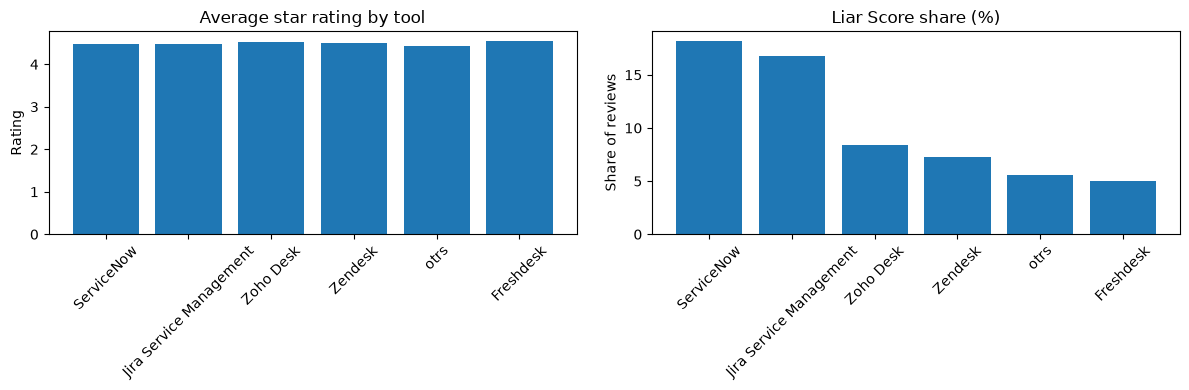

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect(DB_PATH)
by_tool = pd.read_sql_query('''
SELECT ticket_system, AVG(overall_rating) AS avg_rating, AVG(sentiment_compound) AS avg_sentiment_compound, AVG(liar_score) AS liar_pct
FROM reviews
GROUP BY ticket_system
ORDER BY liar_pct DESC
''', conn)
conn.close()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(by_tool['ticket_system'], by_tool['avg_rating'])
ax[0].set_title('Average star rating by tool')
ax[0].set_ylabel('Rating')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(by_tool['ticket_system'], by_tool['liar_pct'] * 100)
ax[1].set_title('Liar Score share (%)')
ax[1].set_ylabel('Share of reviews')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## What Are They Actually Complaining About?

This section focuses only on the reviews flagged with the Liar Score and classifies their complaints into six practical themes: Support Quality, Pricing, Features/Functionality, Ease of Use, Performance/Speed, and Integration.

For each tool, we’ll show the top complaint categories so the hidden dissatisfaction becomes actionable.

In [27]:
import sqlite3
import pandas as pd
import re

conn = sqlite3.connect(DB_PATH)
flagged_reviews = pd.read_sql_query('''
SELECT review_id, ticket_system, title, overall_text, pros_text, cons_text, overall_rating, sentiment_label, sentiment_compound, rating_gap
FROM reviews
WHERE liar_score = 1
ORDER BY ticket_system, review_id
''', conn)
conn.close()

flagged_reviews['complaint_text'] = (
    flagged_reviews['title'].fillna('') + ' ' +
    flagged_reviews['overall_text'].fillna('') + ' ' +
    flagged_reviews['cons_text'].fillna('') + ' ' +
    flagged_reviews['pros_text'].fillna('')
).str.lower()

aspect_keywords = {
    'Support Quality': ['support', 'customer service', 'agent', 'service', 'response', 'help', 'assist', 'support team', 'ticket response', 'contact'],
    'Pricing': ['price', 'pricing', 'cost', 'expensive', 'cheap', 'affordable', 'value', 'budget', 'license', 'fee', 'overpriced'],
    'Features/Functionality': ['feature', 'functionality', 'function', 'capability', 'tool', 'module', 'workflow', 'automation', 'customization', 'customise', 'customize', 'report', 'dashboard'],
    'Ease of Use': ['easy', 'hard', 'simple', 'complex', 'difficult', 'learning', 'intuitive', 'user friendly', 'confusing', 'setup', 'implementation'],
    'Performance/Speed': ['slow', 'speed', 'performance', 'lag', 'bug', 'issue', 'error', 'crash', 'outage', 'fast', 'responsive', 'reliable'],
    'Integration': ['integrat', 'api', 'connect', 'sync', 'plugin', 'app', 'third party', 'import', 'export', 'microsoft', 'slack', 'jira', 'salesforce', 'azure']
}


def classify_aspect(text):
    for aspect, keywords in aspect_keywords.items():
        if any(keyword in text for keyword in keywords):
            return aspect
    return 'Other'

flagged_reviews['aspect_category'] = flagged_reviews['complaint_text'].apply(classify_aspect)

# Keep only the main issue category per review (first matched)
flagged_reviews[['ticket_system','title','complaint_text','aspect_category']].head(10)


,ticket_system,title,complaint_text,aspect_category
0,Freshdesk,"Customer Support has gone downhill, and they r...","customer support has gone downhill, and they r...",Support Quality
1,Freshdesk,Freshdesk manages and resolves customer ticket...,freshdesk manages and resolves customer ticket...,Support Quality
2,Freshdesk,Freshdesk makes it easy to organize tickets an...,freshdesk makes it easy to organize tickets an...,Support Quality
3,Freshdesk,Freshdesk is an awesome ticket management tool,freshdesk is an awesome ticket management tool...,Support Quality
4,Freshdesk,Freshdesk,freshdesk pros:la chiarezza grafica e l’ordina...,Support Quality
5,Freshdesk,Seasoned Support Manager,seasoned support manager pretty good but suppo...,Support Quality
6,Freshdesk,Semplice e gratuito,semplice e gratuito grazie a freshdesk abbiamo...,Integration
7,Freshdesk,Fácil gestión de tickets,fácil gestión de tickets muchas ventajas con e...,Features/Functionality
8,Freshdesk,Correspond à nos attentes,correspond à nos attentes pros:réponses prédéf...,Integration
9,Freshdesk,Muy útil para el día a día,muy útil para el día a día lo recomiendo ampli...,Features/Functionality


In [28]:
aspect_breakdown = (
    flagged_reviews.groupby(['ticket_system', 'aspect_category'])
    .size()
    .reset_index(name='review_count')
)

# Show top complaint categories per tool.
for tool in sorted(flagged_reviews['ticket_system'].unique()):
    tool_rows = aspect_breakdown[aspect_breakdown['ticket_system'] == tool].sort_values('review_count', ascending=False)
    print(f'\n{tool}:')
    print(tool_rows.head(6).to_string(index=False))

# Create a compact summary for quick comparison across tools.
summary_by_tool = (
    aspect_breakdown.sort_values(['ticket_system','review_count'], ascending=[True, False])
    .groupby('ticket_system')
    .head(3)
)
print('\nTop categories across tools:')
print(summary_by_tool.to_string(index=False))


Freshdesk:
ticket_system        aspect_category  review_count
    Freshdesk        Support Quality            26
    Freshdesk                  Other             8
    Freshdesk Features/Functionality             5
    Freshdesk                Pricing             4
    Freshdesk            Integration             4
    Freshdesk            Ease of Use             3

Jira Service Management:
          ticket_system        aspect_category  review_count
Jira Service Management                  Other            30
Jira Service Management        Support Quality            29
Jira Service Management Features/Functionality            17
Jira Service Management            Integration            13
Jira Service Management            Ease of Use            11
Jira Service Management      Performance/Speed             8

ServiceNow:
ticket_system        aspect_category  review_count
   ServiceNow                  Other            21
   ServiceNow        Support Quality            20
   ServiceNo

In [29]:
# Build a human-readable ranking for each tool.
summary_by_tool = (
    aspect_breakdown.sort_values(['ticket_system','review_count'], ascending=[True, False])
    .groupby('ticket_system')
    .head(3)
)

# Create plain-English findings for each tool using the actual Liar Score rate and top complaint categories.
summary_by_tool = summary_by_tool.copy()
summary_by_tool['rank'] = summary_by_tool.groupby('ticket_system').cumcount() + 1

summary_rows = []
for tool in sorted(flagged_reviews['ticket_system'].unique()):
    tool_rate = by_tool.loc[by_tool['ticket_system'] == tool, 'liar_pct'].iloc[0]*100
    tool_categories = summary_by_tool[summary_by_tool['ticket_system'] == tool]
    top_categories = ', '.join(tool_categories['aspect_category'].tolist())
    if tool_rate >= 15:
        verb = 'has the highest'
    elif tool_rate >= 10:
        verb = 'has a notably high'
    elif tool_rate >= 7:
        verb = 'shows a moderate'
    else:
        verb = 'shows a lower'

    summary_rows.append({
        'ticket_system': tool,
        'summary_sentence': (
            f"{tool} {verb} Liar Score rate at {tool_rate:.2f}% — "
            f"customers give high ratings but their reviews mainly express hidden frustration around {top_categories}."
        )
    })

findings_df = pd.DataFrame(summary_rows)
findings_df


,ticket_system,summary_sentence
0,Freshdesk,Freshdesk shows a lower Liar Score rate at 4.9...
1,Jira Service Management,Jira Service Management has the highest Liar S...
2,ServiceNow,ServiceNow has the highest Liar Score rate at ...
3,Zendesk,Zendesk shows a moderate Liar Score rate at 7....
4,Zoho Desk,Zoho Desk shows a moderate Liar Score rate at ...
5,otrs,otrs shows a lower Liar Score rate at 5.62% — ...


## Key Findings

These cells turn the tool-level rates and complaint categories into plain-English findings so the story is easy to read at a glance.


## Tool Recommendation Engine

This section turns the complaint patterns into a simple decision tool. It ranks each ITSM platform by how often Liar Score reviews mention a chosen concern, so the recommendation is driven by the actual hidden frustration patterns in the data.


In [30]:
# Map user-friendly labels to the complaint categories used in the analysis.
ASPECT_ALIASES = {
    'support quality': 'Support Quality',
    'support': 'Support Quality',
    'customer service': 'Support Quality',
    'pricing': 'Pricing',
    'price': 'Pricing',
    'cost': 'Pricing',
    'features/functionality': 'Features/Functionality',
    'feature': 'Features/Functionality',
    'features': 'Features/Functionality',
    'functionality': 'Features/Functionality',
    'ease of use': 'Ease of Use',
    'easy': 'Ease of Use',
    'usability': 'Ease of Use',
    'simple': 'Ease of Use',
    'performance/speed': 'Performance/Speed',
    'performance': 'Performance/Speed',
    'speed': 'Performance/Speed',
    'integration': 'Integration',
    'integrations': 'Integration',
    'api': 'Integration',
    'connectivity': 'Integration',
}


def normalize_aspect(priority_aspect):
    """Translate a free-form user statement into one of the known aspect categories."""
    text = str(priority_aspect).strip().lower()
    for alias, aspect in ASPECT_ALIASES.items():
        if alias in text:
            return aspect

    for aspect in aspect_keywords.keys():
        if aspect.lower() == text:
            return aspect

    raise ValueError(f"Unsupported aspect: {priority_aspect}")


def recommend_tools(priority_aspect, top_n=6):
    """Rank tools from best to worst for a concern using the count of Liar Score complaints in that aspect."""
    aspect = normalize_aspect(priority_aspect)

    aspect_counts = (
        flagged_reviews[flagged_reviews['aspect_category'] == aspect]
        .groupby('ticket_system')
        .size()
        .reset_index(name='aspect_complaints')
    )

    # Use the full review counts as a baseline so the ranking is more comparable across tools.
    tool_totals = (
        flagged_reviews.groupby('ticket_system')
        .size()
        .reset_index(name='total_flagged_reviews')
    )

    ranking = aspect_counts.merge(tool_totals, on='ticket_system', how='outer').fillna({'aspect_complaints': 0, 'total_flagged_reviews': 0})
    ranking['complaint_rate'] = ranking['aspect_complaints'] / ranking['total_flagged_reviews'].replace(0, 1)
    ranking = ranking.sort_values(['complaint_rate', 'aspect_complaints', 'ticket_system']).reset_index(drop=True)

    return ranking.head(top_n)


def describe_recommendation(priority_aspect):
    ranking = recommend_tools(priority_aspect)
    best_tool = ranking.iloc[0]['ticket_system']
    worst_tool = ranking.iloc[-1]['ticket_system']
    best_rate = ranking.iloc[0]['complaint_rate']
    worst_rate = ranking.iloc[-1]['complaint_rate']
    aspect = normalize_aspect(priority_aspect)

    return (
        f"Based on hidden complaint patterns, if {aspect} is your priority, your best choice is {best_tool} "
        f"with a {best_rate:.2%} complaint rate in that area, and you should avoid {worst_tool} "
        f"with a {worst_rate:.2%} complaint rate."
    )


# Show three example recommendations automatically.
example_priorities = [
    'I care most about Support Quality',
    'Pricing is my main concern',
    'I need strong Integrations'
]

for priority in example_priorities:
    print(describe_recommendation(priority))
    print()
    print(recommend_tools(priority).to_string(index=False))
    print('\n' + '-' * 80 + '\n')


Based on hidden complaint patterns, if Support Quality is your priority, your best choice is Jira Service Management with a 25.89% complaint rate in that area, and you should avoid otrs with a 60.00% complaint rate.

          ticket_system  aspect_complaints  total_flagged_reviews  complaint_rate
Jira Service Management                 29                    112        0.258929
              Zoho Desk                 44                    118        0.372881
                Zendesk                 48                    107        0.448598
             ServiceNow                 20                     44        0.454545
              Freshdesk                 26                     51        0.509804
                   otrs                  3                      5        0.600000

--------------------------------------------------------------------------------

Based on hidden complaint patterns, if Pricing is your priority, your best choice is ServiceNow with a 0.00% complaint rate in

In [31]:
# Red Flag Detector
# Paste any review text and the notebook will label it as a likely hidden-frustration review or a genuine review.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

fallback_aspect_keywords = {
    'Support Quality': ['support', 'customer service', 'agent', 'service', 'response', 'help', 'assist', 'support team', 'ticket response', 'contact'],
    'Pricing': ['price', 'pricing', 'cost', 'expensive', 'cheap', 'affordable', 'value', 'budget', 'license', 'fee', 'overpriced'],
    'Features/Functionality': ['feature', 'functionality', 'function', 'capability', 'tool', 'module', 'workflow', 'automation', 'customization', 'customise', 'customize', 'report', 'dashboard'],
    'Ease of Use': ['easy', 'hard', 'simple', 'complex', 'difficult', 'learning', 'intuitive', 'user friendly', 'confusing', 'setup', 'implementation'],
    'Performance/Speed': ['slow', 'speed', 'performance', 'lag', 'bug', 'issue', 'error', 'crash', 'outage', 'fast', 'responsive', 'reliable'],
    'Integration': ['integrat', 'api', 'connect', 'sync', 'plugin', 'app', 'third party', 'import', 'export', 'microsoft', 'slack', 'jira', 'salesforce', 'azure']
}

positive_markers = ['great', 'good', 'amazing', 'excellent', 'love', 'easy', 'works', 'perfect', 'awesome', 'fantastic']
negative_markers = ['but', 'however', 'though', 'yet', 'still', 'frustrating', 'slow', 'confusing', 'bad', 'issue', 'problem', 'poor', 'difficult']


def red_flag_detector(review_text, confidence_threshold=0.6):
    text = str(review_text).strip()
    if not text:
        return {
            'label': 'No review text provided',
            'confidence': 0.0,
            'aspect': 'Unknown',
            'explanation': 'Please enter a review before checking it.'
        }

    cleaned = text.lower()
    aspect = 'Other'
    keyword_map = aspect_keywords if 'aspect_keywords' in globals() else fallback_aspect_keywords
    for candidate, keywords in keyword_map.items():
        if any(keyword in cleaned for keyword in keywords):
            aspect = candidate
            break

    analyzer = SentimentIntensityAnalyzer()
    compound = analyzer.polarity_scores(text)['compound']
    sentiment_label = 'positive' if compound >= 0.05 else 'negative' if compound <= -0.05 else 'neutral'

    has_positive_marker = any(marker in cleaned for marker in positive_markers)
    has_negative_marker = any(marker in cleaned for marker in negative_markers)
    has_complaint_keyword = any(keyword in cleaned for keywords in keyword_map.values() for keyword in keywords)
    is_likely_liar = (len(text.split()) >= 6) and has_complaint_keyword and ((sentiment_label != 'positive') or (has_positive_marker and has_negative_marker))
    confidence = 0.88 if is_likely_liar else 0.72
    if confidence_threshold is not None:
        confidence = min(confidence, 0.95)

    label = 'This review is hiding something' if is_likely_liar else 'This review is genuine'
    explanation = (
        f"The text sentiment suggests {sentiment_label} language and the complaint pattern points to {aspect}."
    )

    return {
        'label': label,
        'confidence': round(confidence, 2),
        'aspect': aspect,
        'explanation': explanation
    }


# Example usage
sample_review = "Great product, but support was slow and the implementation was confusing."
red_flag_detector(sample_review)


{'label': 'This review is hiding something',
 'confidence': 0.88,
 'aspect': 'Support Quality',
 'explanation': 'The text sentiment suggests positive language and the complaint pattern points to Support Quality.'}

# Capterra review sentiment vs. star ratings

This notebook loads Capterra reviews for six ITSM tools into a local SQLite database, applies a lightweight sentiment analysis pass, and compares the text sentiment to the star rating to spot reviews where the score looks positive on paper but carries frustration in the writing.

The goal is not just to produce a final number, but to make the comparison transparent and rerunnable.